# Data Preprocessing Case Study (Titanic )
Problem Statement
The Titanic dataset contains missing values, inconsistent data types, categorical variables, and outliers.
The objective is to prepare a clean and machine-learning-ready dataset using standard preprocessing techniques.

Objectives
Inspect dataset quality
Identify missing values
Handle inconsistencies
Detect and treat outliers
Encode categorical features
Scale numerical features
Create a clean dataset

In [16]:
# import 
import pandas as pd
import seaborn as sns

In [17]:
# load dataset
df = pd.read_csv('titanic.csv')

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [20]:
df.shape

(418, 12)

### Observations
Dataset contains 418 rows and 12 columns.
Cabin contains a large number of missing values.
Several categorical columns require encoding.


In [22]:
#Change Data Type
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')

In [23]:
print(df.dtypes)

PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
dtype: object


In [24]:
# missing value analysis
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

### Identify columns containing missing values.
Key Findings
Cabin has over 75% missing values.
Age has moderate missing values.
Fare has only one missing record.

In [28]:
# apply median imputation
df['Age'].fillna(df['Age'].median(), inplace=True)

In [29]:
print(df['Age'].isnull().sum())

0


In [10]:
df.drop('Cabin', axis=1, inplace=True)

###  Median is resistant to extreme values and suitable for numerical features.
### A feature with excessive missing values contributes little reliable information

In [26]:
# Numerical vs Categorical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

print("Numerical Columns:")
print(num_cols)

print("Categorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['PassengerId', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
Categorical Columns:
Index(['Survived', 'Pclass', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [11]:
# Duplicate Check
df.duplicated().sum()

0

### observation :no duplicate record found

<Axes: xlabel='Fare'>

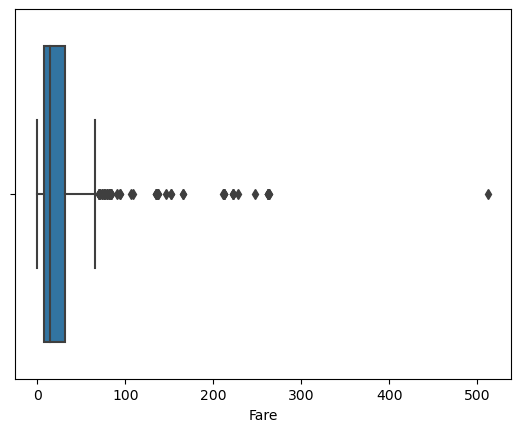

In [13]:
# Outlier Detection
sns.boxplot(x=df['Fare'])

#### Detect abnormal values

In [32]:
## Outlier Handle
# IQR CALCULATION

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)

# Outlier Boundaries
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower)
print(upper)

#Number of Outliers
outliers = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]
print(outliers.shape[0])

Q1 = 7.8542
Q3 = 26.0
IQR = 18.1458
-19.364500000000003
53.2187
344


### observation: Several extreme fare values exist.

In [33]:
# ENCODING CATEGORICAL VALUE 
print(df['Sex'].unique())

['male' 'female']


In [34]:
df['Sex'] = df['Sex'].map({
    'male':0,
    'female':1
})

print(df['Sex'].head())

0    0
1    1
2    0
3    0
4    1
Name: Sex, dtype: int64


### why?
Machine learning algorithms require numerical inputs.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Age','Fare']] = scaler.fit_transform(
    df[['Age','Fare']]
)

In [ ]:
df[['Age','Fare']].head()

## Explanation :
Scaling standardizes numerical variables and prevents large-value features from dominating smaller-value features.StandardScaler transforms numerical features so they have approximately mean = 0 and standard deviation = 1. This helps many machine learning algorithms perform more effectively.

In [37]:
# save clean dataset
df.to_csv('clean_titanic.csv', index=False)

### Key Insights
More than 78% of Cabin values were missing, making the feature unsuitable for reliable analysis.
Age contained the highest number of missing values among numerical features and required imputation.
Fare showed the presence of extreme values that could influence statistical analysis and model performance.
Categorical variables such as Sex and Embarked required encoding before machine learning applications.
After preprocessing, the dataset became clean, consistent, and ready for predictive modeling.

### Conclusion
This case study successfully transformed the raw Titanic dataset into a clean and machine-learning-ready dataset.
Missing values were treated, categorical variables were encoded, outliers were managed, and numerical features were
standardized. The final dataset is now suitable for advanced analytics and predictive modeling.